![image.png](https://i.imgur.com/a3uAqnb.png)
# Lab 6: Large Reasoning Models (GRPO / GSPO)

This notebook focuses on **Large Reasoning Models** — Qwen3 **thinking toggles**, rule-based verifiers, **GRPO/GSPO** group advantages, and self-consistency.

You will score a multi-step math bank with `math_reward`, compare thinking on vs off, sample real completions for majority vote, and visualize accuracy with a bar chart.

> 💡 GRPO replaces a critic with **group-relative** advantages — a key idea from DeepSeek-R1-style post-training.

__Let's install libraries and connect verifiers to a live reasoning model.__


# 📦 Installing Required Python Libraries

This cell installs packages needed for this lab.

- **PyTorch** — Tensor ops for GRPO advantage computation.
- **Transformers / Accelerate** — Load and run instruction-tuned LLMs.
- **Bitsandbytes** (optional) — 4-bit loading for larger models on Colab GPU.


In [7]:
!pip install -q torch transformers accelerate matplotlib numpy

# 📥 Importing Essential Python Libraries

Imports for GRPO utilities and LLM inference in Part B.


In [8]:
import re
import random
from collections import Counter
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch 2.11.0+cu128
CUDA available: True


__Theory first — connect definitions to the lecture slides, then move to code.__

---

## 🧠 Part A — Theory


### 📖 A1. Reasoning & post-training

1. What is **chain-of-thought (CoT)** prompting, and when does it help?
2. Contrast **instruction tuning (SFT)** with **RL from verifiable rewards (RLVR)**.
3. Why can **pattern matching** succeed on benchmarks without true reasoning?

*Write below:*


#### ✍️ Your answers (A1):

1. **CoT prompting** asks the model to **emit intermediate reasoning steps** before the final answer. It helps on **multi-step math, logic, and planning** where direct answers fail.

2. **SFT** imitates human/teacher demonstrations (behavior cloning). **RLVR** optimizes policies with **scalar rewards from verifiable rules** (e.g., math correctness), enabling exploration beyond static demos.

3. Models can **memorize benchmark patterns** or exploit **spurious correlations** (format hacks, answer leakage) without robust **causal reasoning**.

### 📖 A2. GRPO vs PPO

1. How does GRPO compute the **advantage** $A_i$ without a critic network?
2. What is the role of the **KL penalty** to a reference policy $\pi_{\text{ref}}$?
3. Name one task where rule-based rewards work well and one where they do not.

*Write below:*


#### ✍️ Your answers (A2):

1. GRPO sets $A_i = (r_i - \mu_{\text{group}}) / \sigma_{\text{group}}$ — **within-prompt group normalization** replaces a learned **critic/value network**.

2. The **KL penalty** keeps the optimized policy **close to $\pi_{\text{ref}}$**, preventing **reward hacking** and **language drift** during RL.

3. **Works well:** grade-school math with extractable answers. **Works poorly:** open-ended creative writing or subjective tasks without reliable verifiers.

---

## 💻 Part B — Programming
__Let's implement the core ideas in PyTorch.__


### 🛠️ B1. GRPO group advantage

 GRPO (Group Relative Policy Optimization) replaces a critic network by normalizing rewards **within a group** of completions for the same prompt: $A_i = (r_i - \mu) / \sigma$. This is the core DeepSeek-R1-style advantage used in RL post-training.

In [9]:
def grpo_advantages(rewards: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """Normalize rewards within a group: (r - mean) / std."""
    return (rewards - rewards.mean()) / (rewards.std(unbiased=False) + eps)

rewards = torch.tensor([1.0, 0.0, 1.0, 0.5])
adv = grpo_advantages(rewards)
print("Rewards:", rewards.tolist())
print("GRPO advantages:", [round(a, 3) for a in adv.tolist()])

Rewards: [1.0, 0.0, 1.0, 0.5]
GRPO advantages: [0.905, -1.508, 0.905, -0.302]


### 🛠️ B2. Rule-based math verifier

 RL from **verifiable rewards (RLVR)** needs a cheap checker. On GSM8K-style tasks the model must emit a final answer (often after `####`); the verifier returns 1.0 only on an exact match — no human labels required at training time.

In [10]:
def extract_final_answer(text: str):
    """Extract final numeric answer; ignore Qwen3 thinking blocks."""
    think_open = chr(60) + "think" + chr(62)
    think_close = chr(60) + "/think" + chr(62)
    text = re.sub(re.escape(think_open) + r".*?" + re.escape(think_close), "", text, flags=re.DOTALL)
    m = re.search(r"####\s*(-?\d+(?:\.\d+)?)", text)
    if m:
        return m.group(1)
    m = re.search(r"\\boxed\{([^}]+)\}", text)
    if m:
        return m.group(1).strip()
    nums = re.findall(r"-?\d+(?:\.\d+)?", text)
    return nums[-1] if nums else None


def normalize_answer(ans: Optional[str]) -> Optional[str]:
    """Normalize numeric strings so '40' and '40.0' match."""
    if ans is None:
        return None
    try:
        val = float(str(ans).strip().replace(",", ""))
    except ValueError:
        return str(ans).strip()
    if abs(val - round(val)) < 1e-9:
        return str(int(round(val)))
    return str(val)


def math_reward(model_output: str, gold: str) -> float:
    pred = normalize_answer(extract_final_answer(model_output))
    target = normalize_answer(gold)
    return 1.0 if pred is not None and pred == target else 0.0

samples = [("Thought... #### 42", "42"), ("Answer is 41", "42"), ("Result: 40.0", "40")]
for out, gold in samples:
    print(f"output={out!r} gold={gold} reward={math_reward(out, gold)}")

output='Thought... #### 42' gold=42 reward=1.0
output='Answer is 41' gold=42 reward=0.0
output='Result: 40.0' gold=40 reward=1.0


### 🛠️ B3. Qwen3 thinking toggle + question bank

We load **Qwen3** and compare **`enable_thinking=False`** vs **`enable_thinking=True`** on a small multi-step math bank. Each completion is scored with **`math_reward`** from B2, tying the verifier to the live model.

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

no-think 6/6, think 2/6
  gold=14 pred=3 reward=0.0
  gold=150 pred=150 reward=1.0


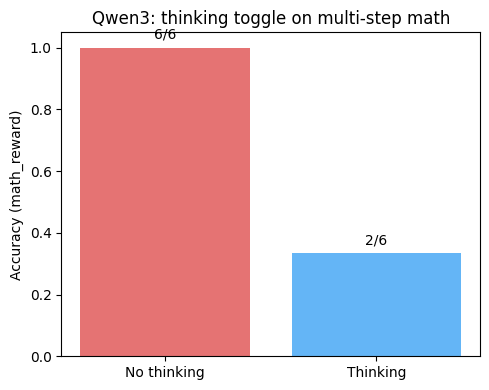

In [12]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL = "Qwen/Qwen3-1.7B"

tokenizer = AutoTokenizer.from_pretrained(MODEL, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    torch_dtype="auto",
    device_map="auto",
    trust_remote_code=True,
)
model.eval()

QUESTION_BANK = [
    {
        "question": "A store sells 3 apples for $2 and 5 oranges for $4. Tom buys 9 apples and 10 oranges. How much does he spend in dollars? Reply with #### followed by the number only.",
        "gold": "14",
    },
    {
        "question": "A tank holds 240 liters and is currently 3/8 full. How many more liters are needed to fill it? Reply with #### followed by the number only.",
        "gold": "150",
    },
    {
        "question": "Two trains start 180 km apart and travel toward each other at 60 km/h and 40 km/h. How many hours until they meet? Reply with #### followed by the number only.",
        "gold": "1.8",
    },
    {
        "question": "A number is tripled, 12 is added, and the result is halved to get 21. What was the original number? Reply with #### followed by the number only.",
        "gold": "10",
    },
    {
        "question": "A rectangular garden is 12 m by 8 m. A 1 m wide path runs inside all four edges. What is the path area in square meters? Reply with #### followed by the number only.",
        "gold": "36",
    },
    {
        "question": "If 5 workers finish a job in 12 days at the same rate, how many days would 8 workers need? Reply with #### followed by the number only.",
        "gold": "7.5",
    },
]


def generate_completions(question: str, enable_thinking: bool, n_samples: int = 1) -> list[str]:
    messages = [{"role": "user", "content": question}]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=enable_thinking,
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    completions = []
    for _ in range(n_samples):
        output_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
        )
        new_tokens = output_ids[0, inputs.input_ids.shape[1] :]
        completions.append(tokenizer.decode(new_tokens, skip_special_tokens=False))
    return completions


def evaluate_bank(enable_thinking: bool) -> tuple[int, int, list[dict]]:
    rows = []
    correct = 0
    for item in QUESTION_BANK:
        completion = generate_completions(item["question"], enable_thinking=enable_thinking, n_samples=1)[0]
        reward = math_reward(completion, item["gold"])
        correct += int(reward == 1.0)
        rows.append(
            {
                "question": item["question"][:60] + "...",
                "gold": item["gold"],
                "pred": extract_final_answer(completion),
                "reward": reward,
                "thinking": enable_thinking,
            }
        )
    return correct, len(QUESTION_BANK), rows

no_think_correct, total, no_think_rows = evaluate_bank(enable_thinking=False)
think_correct, _, think_rows = evaluate_bank(enable_thinking=True)

print(f"no-think {no_think_correct}/{total}, think {think_correct}/{total}")
for row in think_rows[:2]:
    print(f"  gold={row['gold']} pred={row['pred']} reward={row['reward']}")

labels = ["No thinking", "Thinking"]
accuracies = [no_think_correct / total, think_correct / total]
counts = [no_think_correct, think_correct]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, accuracies, color=["#e57373", "#64b5f6"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy (math_reward)")
ax.set_title("Qwen3: thinking toggle on multi-step math")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03, f"{count}/{total}", ha="center")
plt.tight_layout()
plt.show()

### 🛠️ B4. Self-consistency majority vote

We sample **multiple real completions** from Qwen3 (thinking enabled) on one hard question, extract answers with B2, and take a **majority vote** — no hardcoded strings.

In [13]:
SELF_CONSISTENCY_QUESTION = QUESTION_BANK[2]
N_SAMPLES = 5

def self_consistency_vote(sample_outputs: list[str]) -> Optional[str]:
    answers = [normalize_answer(extract_final_answer(s)) for s in sample_outputs]
    answers = [a for a in answers if a is not None]
    if not answers:
        return None
    return Counter(answers).most_common(1)[0][0]

sample_outputs = generate_completions(
    SELF_CONSISTENCY_QUESTION["question"],
    enable_thinking=True,
    n_samples=N_SAMPLES,
)
rewards = [math_reward(s, SELF_CONSISTENCY_QUESTION["gold"]) for s in sample_outputs]
majority = self_consistency_vote(sample_outputs)

print(f"Gold answer: {SELF_CONSISTENCY_QUESTION['gold']}")
print(f"Sample rewards: {rewards}")
print(f"Majority vote: {majority}")
print(f"Majority correct: {math_reward('#### ' + str(majority), SELF_CONSISTENCY_QUESTION['gold']) if majority else 0.0}")

Gold answer: 1.8
Sample rewards: [0.0, 1.0, 1.0, 0.0, 0.0]
Majority vote: 1.8
Majority correct: 1.0


### 🛠️ B5. GSPO sequence-level advantages

**GSPO** assigns one reward per **full completion** and normalizes advantages **within the group** (mean/std), like GRPO in B1 but at sequence granularity — not a log-probability-weighted baseline.

In [14]:
def gspo_advantages(rewards: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """Sequence-level rewards for G completions — group normalize across sequences."""
    return (rewards - rewards.mean()) / (rewards.std(unbiased=False) + eps)

# One reward per sampled completion in B4
rewards = torch.tensor(rewards, dtype=torch.float32)
adv = gspo_advantages(rewards)
print("Sequence rewards:", rewards.tolist())
print("GSPO advantages:", [round(a, 3) for a in adv.tolist()])

Sequence rewards: [0.0, 1.0, 1.0, 0.0, 0.0]
GSPO advantages: [-0.816, 1.225, 1.225, -0.816, -0.816]
